#### Business Problem
- Whether customer will churn/exist or not

In [3]:
import numpy as np
import pandas as pd

In [4]:
## Churn Modelling to predict whether the customer will leave the bank  or not
df = pd.read_csv("Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [5]:
# no. of unique values in each column
df["Exited"].unique() # Binary Classification

array([1, 0])

**Data Understanding**

In [6]:
df.columns.to_list()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [7]:
print("Geography:", df["Geography"].nunique())
print("Gender:", df["Gender"].nunique())
print("HasCrCard:", df["HasCrCard"].nunique())
print("IsActiveMember:", df["IsActiveMember"].nunique())
print("NumOfProducts:", df["NumOfProducts"].nunique())
print("Tenure:", df["Tenure"].nunique())
print("CreditScore:", df["CreditScore"].nunique())
print("Age:", df["Age"].nunique())
print("Balance:", df["Balance"].nunique())
print("EstimatedSalary:", df["EstimatedSalary"].nunique())
print("Exited:", df["Exited"].nunique())

Geography: 3
Gender: 2
HasCrCard: 2
IsActiveMember: 2
NumOfProducts: 4
Tenure: 11
CreditScore: 460
Age: 70
Balance: 6382
EstimatedSalary: 9999
Exited: 2


**Data Cleaning**

In [8]:
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [9]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [10]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [11]:
X = pd.get_dummies(df.drop('Exited',axis=1), drop_first=True)
y = df['Exited']

In [13]:
### Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X , y, test_size=0.2, random_state=0)

In [14]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [15]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((8000, 11), (2000, 11), (8000,), (2000,))

In [ ]:
# Scaling is applied only to classification problems and not to regression problems because in regression problems, the output variable is continuous and can take any value. So we do not need to scale the features in regression problems. 
# But in classification problems, the output variable is categorical and can take only a limited number of values. So we need to scale the features in classification problems to bring all the features to the same scale.
## Scaling is the solution to the problem of different scales of the features. ANN is sensitive to the scale of the data. So we need to scale the features before training the ANN.
## Scaling  means that we will bring all the features to the same scale. This is done by subtracting the mean and dividing by the standard deviation. This will bring all the features to a scale of 0 to 1.
## Scaling the features because ANN is sensitive to the scale of the data
## Here in this dataset, the features are in different scales. So we will scale the features using StandardScaler
## Balance and EstimatedSalary are in different scales. So we will scale these features.
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
## In scalling we fit the scaler on the training data and then transform both the training and test data. This is to avoid data leakage from the test set to the training set.
## Scalinfg is done to bring all the features to the same scale so that the ANN can learn effectively. If we do not scale the features, then the ANN may give more importance to the features which are in higher scales and less importance to the features which are in lower scales. This can lead to poor performance of the model.

##### Data Modelling
**Initializing the Artificial Neural Network**

In [17]:
import tensorflow as tf
import keras

from keras.models import Sequential
from keras.layers import Dense

In [26]:
## Initialising the ANN
p_model = Sequential()

# Hidden layer with relu activation function and output layer with sigmoid activation function
p_model.add(Dense(input_dim=11, units = 22, activation='relu', kernel_initializer='uniform'))
p_model.add(Dense(units=22, activation='relu', kernel_initializer='uniform'))
p_model.add(Dense(units=1, activation='sigmoid', kernel_initializer='uniform'))

p_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## training the ANN on the Training set
p_model.fit(x_train, y_train, batch_size=32, epochs=100)

c:\Users\nirmi\anaconda3\envs\dl_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 997us/step - accuracy: 0.7951 - loss: 0.5062
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7994 - loss: 0.4269  
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8263 - loss: 0.4175  
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - accuracy: 0.8330 - loss: 0.4094
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8359 - loss: 0.4055  
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8375 - loss: 0.4019
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8364 - loss: 0.3997  
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8376 - loss: 0.3986  
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8359 - loss: 0.3970  
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8366 - loss: 0.3956  
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.8395 - loss: 0.3951
Epoch 12/100
250/250 

**Predictions**

In [27]:
y_pred_train = p_model.predict(x_train)
y_pred_train = (y_pred_train >= 0.5)

y_pred_test = p_model.predict(x_test)
y_pred_test = (y_pred_test >= 0.5)

# Above code is for training the ANN and making predictions on the training and test set. 
# We have used sigmoid activation function in the output layer because we are doing binary classification. 
# We have used binary_crossentropy as the loss function because we are doing binary classification.
# We have used adam optimizer because it is a good optimizer for training neural networks. 
# We have used accuracy as the metric to evaluate the performance of the model.

# >= 0.5 is used to convert the predicted probabilities into binary values. 
# If the predicted probability is greater than or equal to 0.5, then we will classify it as 1 (customer will leave the bank), otherwise we will classify it as 0 (customer will not leave the bank).

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


**Evaluations**

In [29]:
from sklearn.metrics import confusion_matrix, accuracy_score
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
# Above code is for evaluating the performance of the model using confusion matrix and accuracy score.
# We can see that the accuracy on the training set is 0.85 and the accuracy on the test set is 0.86. This means that our model is performing well on both the training and test set.

Train Accuracy: 0.872625
Test Accuracy: 0.852


##### Predictions & Evaluation the Model
**Predictions**

In [30]:
y_pred = p_model.predict(x_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step


**Evaluations**

In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

confusion_matrix(y_test, y_pred)
# confusion matrix is a table that is used to evaluate the performance of a classification model. It is a 2x2 matrix that shows the number of true positives, true negatives, false positives, and false negatives.
# The confusion matrix shows that there are 1525 true negatives (TN), 70 false positives (FP), 309 false negatives (FN), and 96 true positives (TP).
#          Predicted
#          0   1
# Actual 0 
#        1
# TN -> 1525 (customer will not leave the bank and the model predicted that the customer will not leave the bank)
# FP -> 70 (customer will not leave the bank but the model predicted that the customer will leave the bank)
# FN -> 309 (customer will leave the bank but the model predicted that the customer will not leave the bank)
# TP -> 96 (customer will leave the bank and the model predicted that the customer will leave the bank)

# 1526 + 96 = 1621 (total number of customers who will not leave the bank) Correctly Predicted
# 70 + 309 = 379 (total number of customers who will leave the bank ) Incorrectly Predicted

# accuracy = (TN + TP) / (TN + FP + FN + TP)
# accuracy = (1525 + 96) / (1525 + 70 + 309 + 96)
# accuracy = 1621 / 2000 = 0.8105

Train Accuracy: 0.872625
Test Accuracy: 0.852


array([[1489,  106],
       [ 190,  215]])

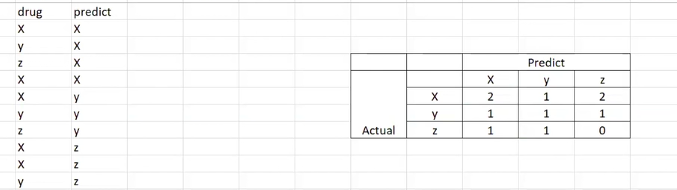

##### Cross Validate the Model